# v2 调优结果可视化：与 v1 基线对比

本 notebook 用于回答两个相互关联的问题：

1. 使用验证集最优参数后，v2 中五个模型的总体表现、长预测步长稳定性和效率表现如何？
2. 与 v1 未调参基线相比，调优究竟改善了哪些模型、数据集、预测步长和评价指标？

## 实验范围

| 项目 | v1 | v2 |
|---|---|---|
| 运行标签 | `formal_seed42` | `full_val_best_e50p10_tb_seed42` |
| 数据集 | ETTh1、ETTm1 | ETTh1、ETTm1 |
| 预测步长 | 24、48、96、168、336 | 24、48、96、168、336 |
| 模型 | LSTM、Transformer、Informer、Autoformer、PatchTST | 相同五个模型 |
| 任务数量 | 50 | 50 |

## 指标口径

- `MSE`：均方误差，对少量较大的预测偏差更敏感，越低越好。
- `MAE`：平均绝对误差，更接近平均偏差的直观量级，越低越好。
- `R2`：决定系数，越高越好；低于 0 表示还不如直接预测测试集均值。
- `MSE_target / MAE_target / R2_target`：只计算目标变量列，不能与全变量平均指标混为一谈。
- `train_time_seconds / model_params`：用于讨论训练成本和模型规模，不直接代表预测质量。

所有 v1/v2 对比均按 `dataset × horizon × model` 一一匹配。图表保存到
`archive/v2_results/experiments/validation_best_full_matrix/figures/`。


## 1. 读取并校验 v1、v2 汇总表

本节不是简单地读取两个 CSV，而是先验证它们能否进行公平对比：

- 两版必须各有 50 条记录；
- 数据集、预测步长和模型集合必须相同；
- 每个 `dataset × horizon × model` 组合只能出现一次；
- v1 与 v2 的任务键集合必须完全一致。

如果这些条件不满足，后续平均值可能会把缺失任务或重复任务掩盖掉，因此应直接停止分析并修复数据。


In [1]:
# 本单元集中完成依赖导入、绘图风格和项目路径初始化。
# 后续单元只负责分析与绘图，避免在每张图前重复设置环境。
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# 统一三本可视化 Notebook 的基础样式：
# 适度提高分辨率、保留浅色网格，并去掉上/右边框，使多子图更清楚。
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# 固定模型顺序，防止 pandas 按字母顺序重排后，不同图中的颜色和位置发生变化。
# LABELS 用于面向读者显示规范名称，COLORS 保证同一模型跨图始终使用同一种颜色。
MODEL_ORDER = ["lstm", "transformer", "informer", "autoformer", "patchtst"]
MODEL_LABELS = {
    "lstm": "LSTM",
    "transformer": "Transformer",
    "informer": "Informer",
    "autoformer": "Autoformer",
    "patchtst": "PatchTST",
}
MODEL_COLORS = {
    "lstm": "#6B7280",
    "transformer": "#8B5CF6",
    "informer": "#14B8A6",
    "autoformer": "#E45756",
    "patchtst": "#2F6F73",
}


# Notebook 可能从项目根目录、notebooks/visualization/ 或 nbconvert 临时环境启动。
# 因此向上搜索同时含 README.md 与 archive/ 的目录，而不是依赖固定的当前工作目录。
def find_project_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "README.md").exists() and (base / "archive").exists():
            return base
    raise FileNotFoundError("Cannot locate the Research-Training project root")


# ROOT 是后续所有输入和输出路径的唯一基准，保证移动项目目录后相对结构仍然有效。
ROOT = find_project_root()


# 只读取归档中的正式汇总表，避免误用项目根目录中的临时结果。
# v1 是未调参基线，v2 是验证集最优配置后的完整矩阵。
V1_CSV = ROOT / "archive/v1_results/experiments/formal_baseline/summaries/csv/formal_seed42_all.csv"
V2_CSV = ROOT / "archive/v2_results/experiments/validation_best_full_matrix/summaries/csv/full_val_best_e50p10_tb_seed42_summary.csv"
FIG_DIR = ROOT / "archive/v2_results/experiments/validation_best_full_matrix/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 将 horizon 统一转为整数，避免 CSV 类型推断差异影响排序、集合比较和绘图刻度。
v1 = pd.read_csv(V1_CSV)
v2 = pd.read_csv(V2_CSV)
for frame in (v1, v2):
    frame["horizon"] = frame["horizon"].astype(int)

# 这三个字段共同定义一个可比较任务；run_tag 不加入键，因为两版标签本来就不同。
keys = ["dataset", "horizon", "model"]
expected_horizons = [24, 48, 96, 168, 336]
# 先检查规模和任务集合，再计算任何均值。
# 如果某版缺失一组实验，直接平均会造成不公平且不易察觉的比较偏差。
assert len(v1) == len(v2) == 50
assert sorted(v1["horizon"].unique()) == expected_horizons
assert sorted(v2["horizon"].unique()) == expected_horizons
assert set(map(tuple, v1[keys].to_numpy())) == set(map(tuple, v2[keys].to_numpy()))

display(Markdown(
    f"Loaded **{len(v1)} v1 rows** and **{len(v2)} v2 rows**. "
    "All 50 tasks are aligned."
))
display(v2.head())

Loaded **50 v1 rows** and **50 v2 rows**. All 50 tasks are aligned.

,dataset,horizon,model,run_tag,MSE,MAE,R2,MSE_target,MAE_target,R2_target,...,trained_epochs,seed,sample_limit,train_samples,val_samples,test_samples,model_params,train_time_seconds,device,data_dir
0,ETTh1,24,autoformer,full_val_best_e50p10_tb_seed42,0.451223,0.440573,0.646957,0.045546,0.160291,0.705958,...,21,42,0,8521,2761,5781,89271,107.903650,cuda,/root/demo/data/processed
1,ETTh1,24,informer,full_val_best_e50p10_tb_seed42,0.750386,0.634169,0.412889,0.373369,0.502442,-1.410426,...,18,42,0,8521,2761,5781,182175,91.881156,cuda,/root/demo/data/processed
2,ETTh1,24,lstm,full_val_best_e50p10_tb_seed42,0.942513,0.682829,0.262566,0.140437,0.302500,0.093356,...,15,42,0,8521,2761,5781,380328,61.805024,cuda,/root/demo/data/processed
3,ETTh1,24,patchtst,full_val_best_e50p10_tb_seed42,0.369151,0.400706,0.711172,0.041484,0.157652,0.732184,...,23,42,0,8521,2761,5781,77488,34.583566,cuda,/root/demo/data/processed
4,ETTh1,24,transformer,full_val_best_e50p10_tb_seed42,0.784316,0.651812,0.386342,0.195583,0.365012,-0.262664,...,42,42,0,8521,2761,5781,238376,180.951370,cuda,/root/demo/data/processed


## 2. v2 覆盖范围与模型平均表现

第一张表用于核对两版的覆盖规模。第二张表按模型聚合 v2 的 10 个任务，即
`2 个数据集 × 5 个预测步长`。

这里使用算术平均，是为了得到便于横向比较的总体指标；但不同预测步长的难度并不相同，因此平均结果只能用于总体排序，具体退化趋势仍需结合下一节曲线判断。

`train_time_seconds` 使用求和，表示该模型完成所有任务的总训练时间；`trained_epochs` 和
`model_params` 使用平均值，用于观察典型训练轮数和模型规模。


In [2]:
# coverage 是完整性摘要，不参与性能计算；它帮助读者先确认比较范围相同。
coverage = pd.DataFrame({
    "version": ["v1 baseline", "v2 tuned"],
    "rows": [len(v1), len(v2)],
    "datasets": [v1["dataset"].nunique(), v2["dataset"].nunique()],
    "horizons": [v1["horizon"].nunique(), v2["horizon"].nunique()],
    "models": [v1["model"].nunique(), v2["model"].nunique()],
})

# 每个模型正好包含 10 个任务，因此这里的模型平均不会受到任务数量不均衡影响。
# 训练时间使用 sum 表示完成整套矩阵的成本，其余统计量描述典型平均表现。
v2_avg = (
    v2.groupby("model", as_index=False)
    .agg(
        MSE=("MSE", "mean"),
        MAE=("MAE", "mean"),
        R2=("R2", "mean"),
        MSE_target=("MSE_target", "mean"),
        MAE_target=("MAE_target", "mean"),
        R2_target=("R2_target", "mean"),
        train_time_seconds=("train_time_seconds", "sum"),
        trained_epochs=("trained_epochs", "mean"),
        model_params=("model_params", "mean"),
    )
    .sort_values("MSE")
)

# 先显示覆盖情况，再显示格式化后的模型平均表，阅读顺序与分析逻辑一致。
display(coverage)
display(v2_avg.style.format({
    "MSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}",
    "MSE_target": "{:.4f}", "MAE_target": "{:.4f}", "R2_target": "{:.4f}",
    "train_time_seconds": "{:.1f}", "trained_epochs": "{:.1f}", "model_params": "{:.0f}",
}))

,version,rows,datasets,horizons,models
0,v1 baseline,50,2,5,5
1,v2 tuned,50,2,5,5


,model,MSE,MAE,R2,MSE_target,MAE_target,R2_target,train_time_seconds,trained_epochs,model_params
3,patchtst,0.4626,0.4497,0.6366,0.0772,0.2030,0.5055,586.5,19.3,113037
0,autoformer,0.5016,0.4779,0.6061,0.0949,0.2234,0.3920,883.2,16.2,110689
4,transformer,0.8217,0.6740,0.3547,0.3736,0.4947,-1.3979,826.0,25.6,338067
1,informer,0.8901,0.6860,0.3010,0.5254,0.5678,-2.3718,671.3,13.5,192884
2,lstm,0.9871,0.6998,0.2249,0.2651,0.4026,-0.6986,411.1,14.0,578938


## 3. v2 五模型平均指标

六张子图分为两行：

- 第一行评价全部变量的平均预测表现；
- 第二行只评价目标变量。

MSE、MAE 柱越低越好，R2 柱越高越好。需要特别注意：某模型可能在全变量指标上领先，却不一定在目标变量上领先，因此报告中应分别表述“整体多变量预测”和“目标列预测”。

图中颜色只表示模型身份，不表示性能等级；性能高低应根据坐标轴方向判断。


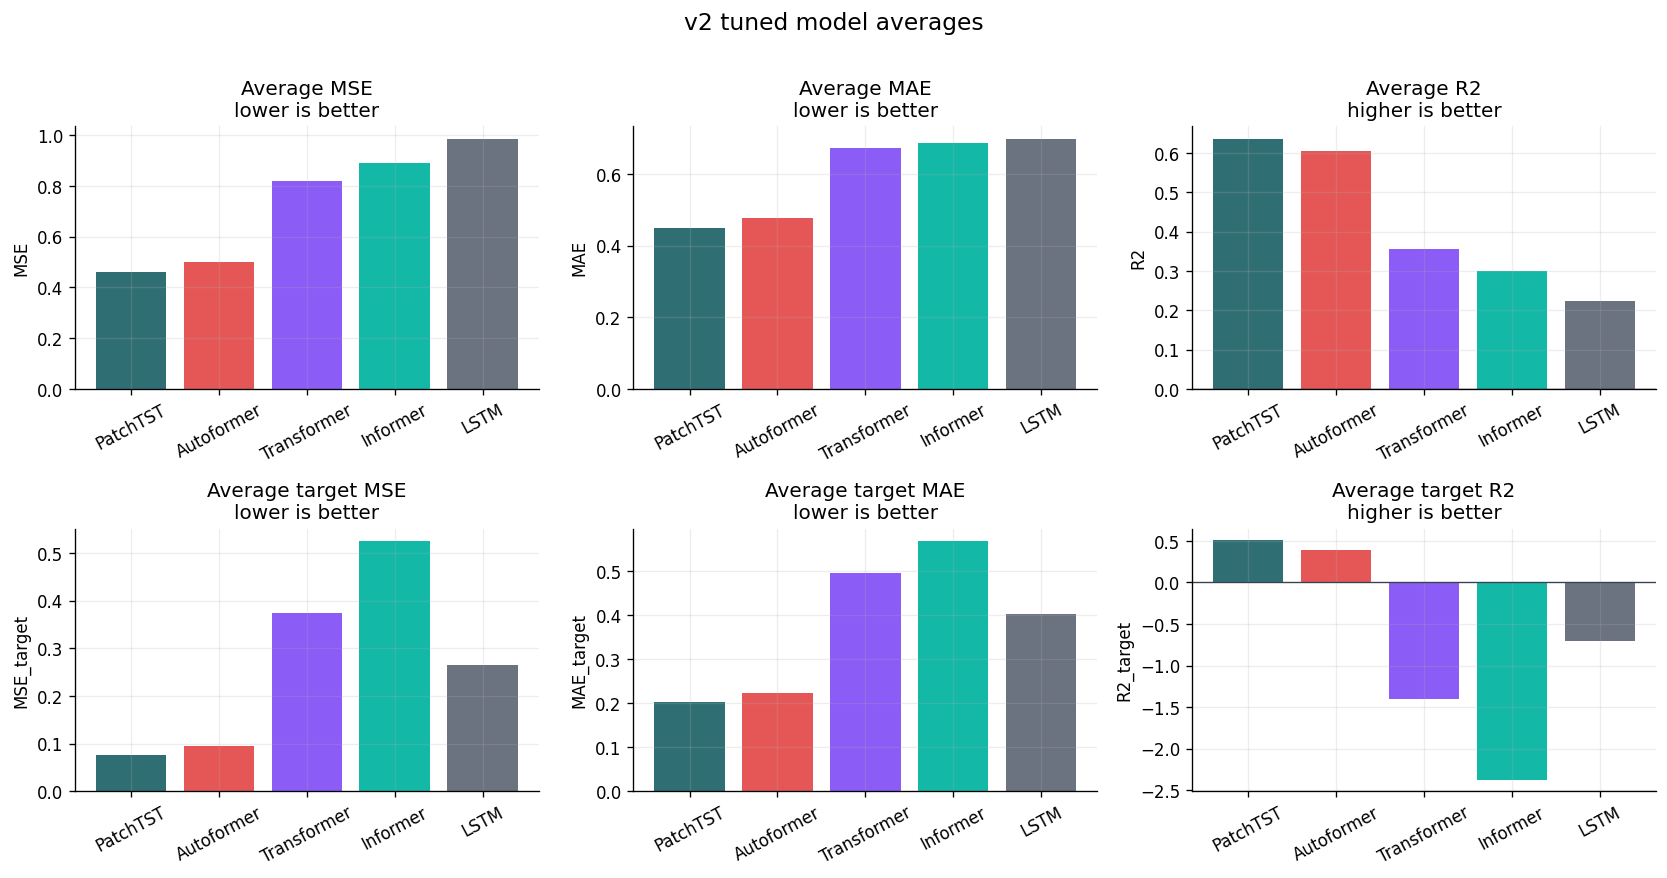

In [3]:
# 使用 2×3 布局把全变量指标和目标变量指标分开，避免读者混淆评价对象。
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2))
# higher_better 显式记录指标方向；R2 需要显示 0 基准线，误差指标则不需要。
metrics = [
    ("MSE", "Average MSE", False),
    ("MAE", "Average MAE", False),
    ("R2", "Average R2", True),
    ("MSE_target", "Average target MSE", False),
    ("MAE_target", "Average target MAE", False),
    ("R2_target", "Average target R2", True),
]
plot_order = v2_avg["model"].tolist()

# 使用固定模型顺序和固定颜色，让六张子图可以快速横向比较。
for ax, (metric, title, higher_better) in zip(axes.ravel(), metrics):
    values = v2_avg.set_index("model").loc[plot_order, metric]
    ax.bar(
        [MODEL_LABELS[m] for m in values.index],
        values,
        color=[MODEL_COLORS[m] for m in values.index],
    )
    ax.set_title(f"{title}\n{'higher' if higher_better else 'lower'} is better")
    ax.tick_params(axis="x", rotation=28)
    ax.set_ylabel(metric)
    if higher_better:
        ax.axhline(0, color="#374151", linewidth=0.8)

fig.suptitle("v2 tuned model averages", y=1.01, fontsize=14)
fig.tight_layout()
# bbox_inches='tight' 防止旋转后的模型标签在保存 PNG 时被裁掉。
fig.savefig(FIG_DIR / "v2_model_average_metrics.png", bbox_inches="tight")
plt.show()

## 4. 预测步长变化趋势

每一列固定一个数据集，上行为全变量 MSE，下行为目标变量 MSE。横轴从 24 增加到 336，代表模型需要一次预测更远的未来。

读图时重点观察：

1. 曲线整体高度：越低说明误差越小；
2. 曲线斜率：上升越快，说明长步长误差累积越明显；
3. 曲线交叉：表示模型排名会随预测距离变化，不能只用单个 horizon 概括；
4. 全变量和目标变量曲线是否一致：若不一致，应在结论中区分两种评价口径。


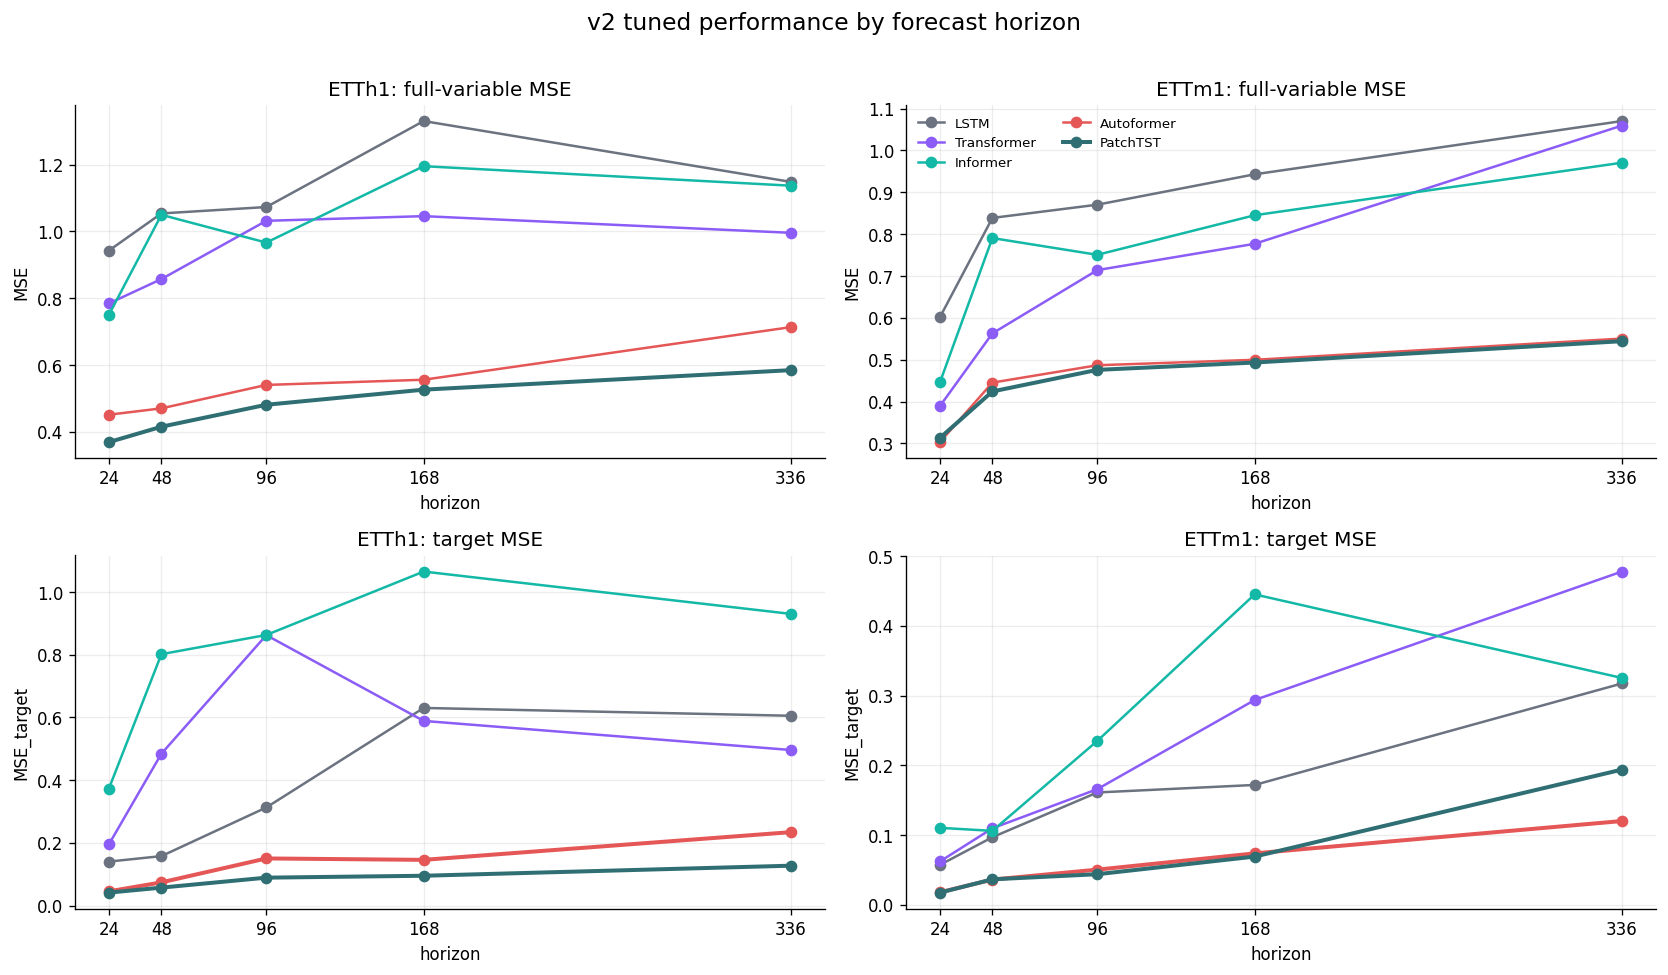

In [4]:
# 每列对应一个数据集；每行对应一种 MSE 口径，共用固定的 horizon 刻度。
datasets = sorted(v2["dataset"].unique())
fig, axes = plt.subplots(2, 2, figsize=(14, 8.0))

# 先按数据集筛选，再按模型连接五个预测步长，确保曲线只表示 horizon 的变化。
for col, dataset in enumerate(datasets):
    subset = v2[v2["dataset"] == dataset]
    for model in MODEL_ORDER:
        group = subset[subset["model"] == model].sort_values("horizon")
        axes[0, col].plot(
            group["horizon"], group["MSE"], marker="o",
            # 对项目主要竞争模型适度加粗，只用于视觉引导，不改变数据或排序结果。
linewidth=2.4 if model == "patchtst" else 1.5,
            color=MODEL_COLORS[model], label=MODEL_LABELS[model],
        )
        axes[1, col].plot(
            group["horizon"], group["MSE_target"], marker="o",
            linewidth=2.4 if model in {"patchtst", "autoformer"} else 1.5,
            color=MODEL_COLORS[model], label=MODEL_LABELS[model],
        )
    axes[0, col].set_title(f"{dataset}: full-variable MSE")
    axes[1, col].set_title(f"{dataset}: target MSE")
    for row in range(2):
        axes[row, col].set_xticks(expected_horizons)
        axes[row, col].set_xlabel("horizon")
        axes[row, col].set_ylabel("MSE" if row == 0 else "MSE_target")

# 只保留一个公共图例，减少四个子图重复图例造成的遮挡。
axes[0, 1].legend(fontsize=8, frameon=False, ncol=2)
fig.suptitle("v2 tuned performance by forecast horizon", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_horizon_trends.png", bbox_inches="tight")
plt.show()

## 5. v2 每个任务的冠军与胜出次数

对每个 `dataset × horizon` 任务分别选择：

- 全变量 `MSE` 最低的模型；
- 目标变量 `MSE_target` 最低的模型。

胜出次数反映跨数据集、跨步长的稳定性，但它不体现领先幅度。例如领先 0.001 和领先 0.1 都只计一次，因此应与上一节的实际误差曲线共同使用。


,dataset,horizon,best_MSE_model,MSE,best_target_model,MSE_target
0,ETTh1,24,PatchTST,0.3692,PatchTST,0.0415
1,ETTh1,48,PatchTST,0.4152,PatchTST,0.0574
2,ETTh1,96,PatchTST,0.4810,PatchTST,0.0892
3,ETTh1,168,PatchTST,0.5261,PatchTST,0.0952
4,ETTh1,336,PatchTST,0.5845,PatchTST,0.1273
5,ETTm1,24,Autoformer,0.3030,PatchTST,0.0175
6,ETTm1,48,PatchTST,0.4241,Autoformer,0.0362
7,ETTm1,96,PatchTST,0.4757,PatchTST,0.0439
8,ETTm1,168,PatchTST,0.4932,PatchTST,0.0692
9,ETTm1,336,PatchTST,0.5442,Autoformer,0.1201


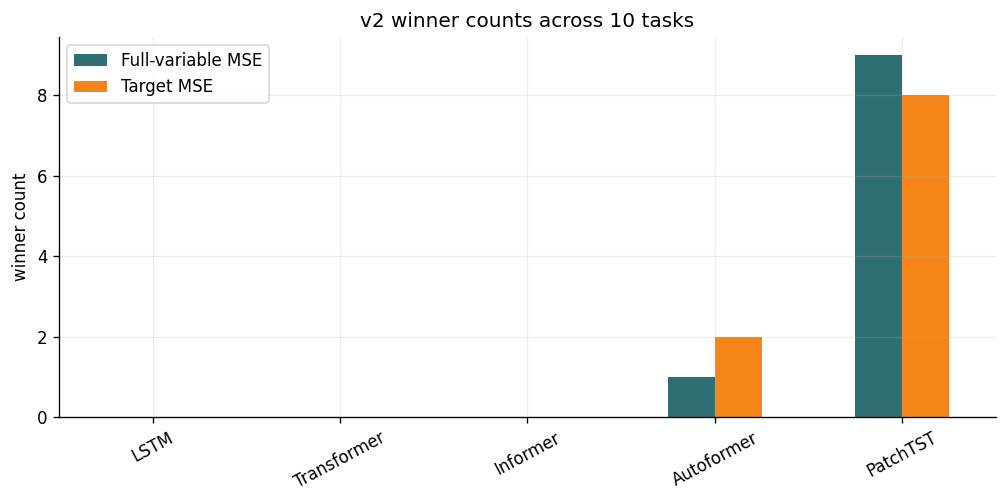

,Full-variable MSE,Target MSE
LSTM,0,0
Transformer,0,0
Informer,0,0
Autoformer,1,2
PatchTST,9,8


In [5]:
# 每个 dataset×horizon 任务分别寻找全变量冠军和目标变量冠军。
# idxmin 返回原始行索引，因此先保留完整行，再提取模型和对应误差。
winner_rows = []
for (dataset, horizon), group in v2.groupby(["dataset", "horizon"]):
    best_full = group.loc[group["MSE"].idxmin()]
    best_target = group.loc[group["MSE_target"].idxmin()]
    winner_rows.append({
        "dataset": dataset,
        "horizon": int(horizon),
        "best_MSE_model": MODEL_LABELS[best_full["model"]],
        "MSE": best_full["MSE"],
        "best_target_model": MODEL_LABELS[best_target["model"]],
        "MSE_target": best_target["MSE_target"],
    })

# 明细表保留每个任务的获胜误差，便于检查“赢了多少次”和“领先多少”之间的差别。
winners = pd.DataFrame(winner_rows).sort_values(["dataset", "horizon"])
display(winners.style.format({"MSE": "{:.4f}", "MSE_target": "{:.4f}"}))

# 将两个评价口径的胜出次数并排统计；没有获胜的模型通过 reindex 补为 0。
full_counts = winners["best_MSE_model"].value_counts()
target_counts = winners["best_target_model"].value_counts()
counts = pd.concat([full_counts, target_counts], axis=1).fillna(0)
counts.columns = ["Full-variable MSE", "Target MSE"]
counts = counts.reindex([MODEL_LABELS[m] for m in MODEL_ORDER], fill_value=0)

ax = counts.plot(kind="bar", figsize=(8.5, 4.3), color=["#2F6F73", "#F58518"])
ax.set_title("v2 winner counts across 10 tasks")
ax.set_xlabel("")
ax.set_ylabel("winner count")
ax.tick_params(axis="x", rotation=28)
plt.tight_layout()
plt.savefig(FIG_DIR / "v2_winner_counts.png", bbox_inches="tight")
plt.show()
display(counts.astype(int))

## 6. v1 与 v2 的严格配对比较

本节通过一对一合并保证每条 v1 记录只对应一条 v2 记录。模型平均对比包含四类变化：

- `MSE_change_pct = (MSE_v2 / MSE_v1 - 1) × 100%`
- `R2_change = R2_v2 - R2_v1`
- `target_MSE_change_pct`：同样公式，但只评价目标变量；
- `target_R2_change`：目标变量 R2 的绝对变化。

因此，MSE 百分比变化为负表示调优有效，R2 变化为正表示拟合优度提高。百分比变化不适用于接近 0 的 R2，所以 R2 使用绝对差值。


In [6]:
# validate='one_to_one' 会在任一版本出现重复任务时直接报错，是公平配对的重要保护。
merged = v1.merge(v2, on=keys, suffixes=("_v1", "_v2"), validate="one_to_one")
assert len(merged) == 50

# 先在 50 个严格配对任务上合并，再按模型聚合，避免独立平均后任务集合不一致。
comparison = (
    merged.groupby("model", as_index=False)
    .agg(
        MSE_v1=("MSE_v1", "mean"),
        MSE_v2=("MSE_v2", "mean"),
        R2_v1=("R2_v1", "mean"),
        R2_v2=("R2_v2", "mean"),
        target_MSE_v1=("MSE_target_v1", "mean"),
        target_MSE_v2=("MSE_target_v2", "mean"),
        target_R2_v1=("R2_target_v1", "mean"),
        target_R2_v2=("R2_target_v2", "mean"),
    )
    # MSE 使用相对变化便于比较不同误差量级；R2 可能为负或接近 0，因此使用绝对差值。
.assign(
        MSE_change_pct=lambda x: (x["MSE_v2"] / x["MSE_v1"] - 1) * 100,
        R2_change=lambda x: x["R2_v2"] - x["R2_v1"],
        target_MSE_change_pct=lambda x: (x["target_MSE_v2"] / x["target_MSE_v1"] - 1) * 100,
        target_R2_change=lambda x: x["target_R2_v2"] - x["target_R2_v1"],
    )
    .sort_values("MSE_v2")
)

display(comparison.style.format({
    "MSE_v1": "{:.4f}", "MSE_v2": "{:.4f}", "MSE_change_pct": "{:+.1f}%",
    "R2_v1": "{:.4f}", "R2_v2": "{:.4f}", "R2_change": "{:+.4f}",
    "target_MSE_v1": "{:.4f}", "target_MSE_v2": "{:.4f}", "target_MSE_change_pct": "{:+.1f}%",
    "target_R2_v1": "{:.4f}", "target_R2_v2": "{:.4f}", "target_R2_change": "{:+.4f}",
}))

,model,MSE_v1,MSE_v2,R2_v1,R2_v2,target_MSE_v1,target_MSE_v2,target_R2_v1,target_R2_v2,MSE_change_pct,R2_change,target_MSE_change_pct,target_R2_change
3,patchtst,0.4693,0.4626,0.6314,0.6366,0.0776,0.0772,0.5026,0.5055,-1.4%,+0.0053,-0.6%,+0.0029
0,autoformer,0.5147,0.5016,0.5958,0.6061,0.0894,0.0949,0.4266,0.3920,-2.5%,+0.0103,+6.1%,-0.0346
4,transformer,0.9173,0.8217,0.2797,0.3547,0.5464,0.3736,-2.5086,-1.3979,-10.4%,+0.0751,-31.6%,+1.1107
1,informer,0.8170,0.8901,0.3584,0.3010,0.5131,0.5254,-2.2919,-2.3718,+8.9%,-0.0573,+2.4%,-0.0799
2,lstm,0.9461,0.9871,0.2570,0.2249,0.3605,0.2651,-1.3116,-0.6986,+4.3%,-0.0321,-26.5%,+0.6130


## 7. v1/v2 模型平均指标对比图

四张子图把模型平均结果并排展示：

- 左上：全变量平均 MSE；
- 右上：全变量平均 R2；
- 左下：目标变量平均 MSE；
- 右下：目标变量平均 R2。

同一模型中，灰色是 v1，绿色是 v2。调优不一定让所有模型和所有指标同时改善；若 MSE 与 R2 给出不同信号，应回到逐任务数据检查是否由个别数据集或步长造成。


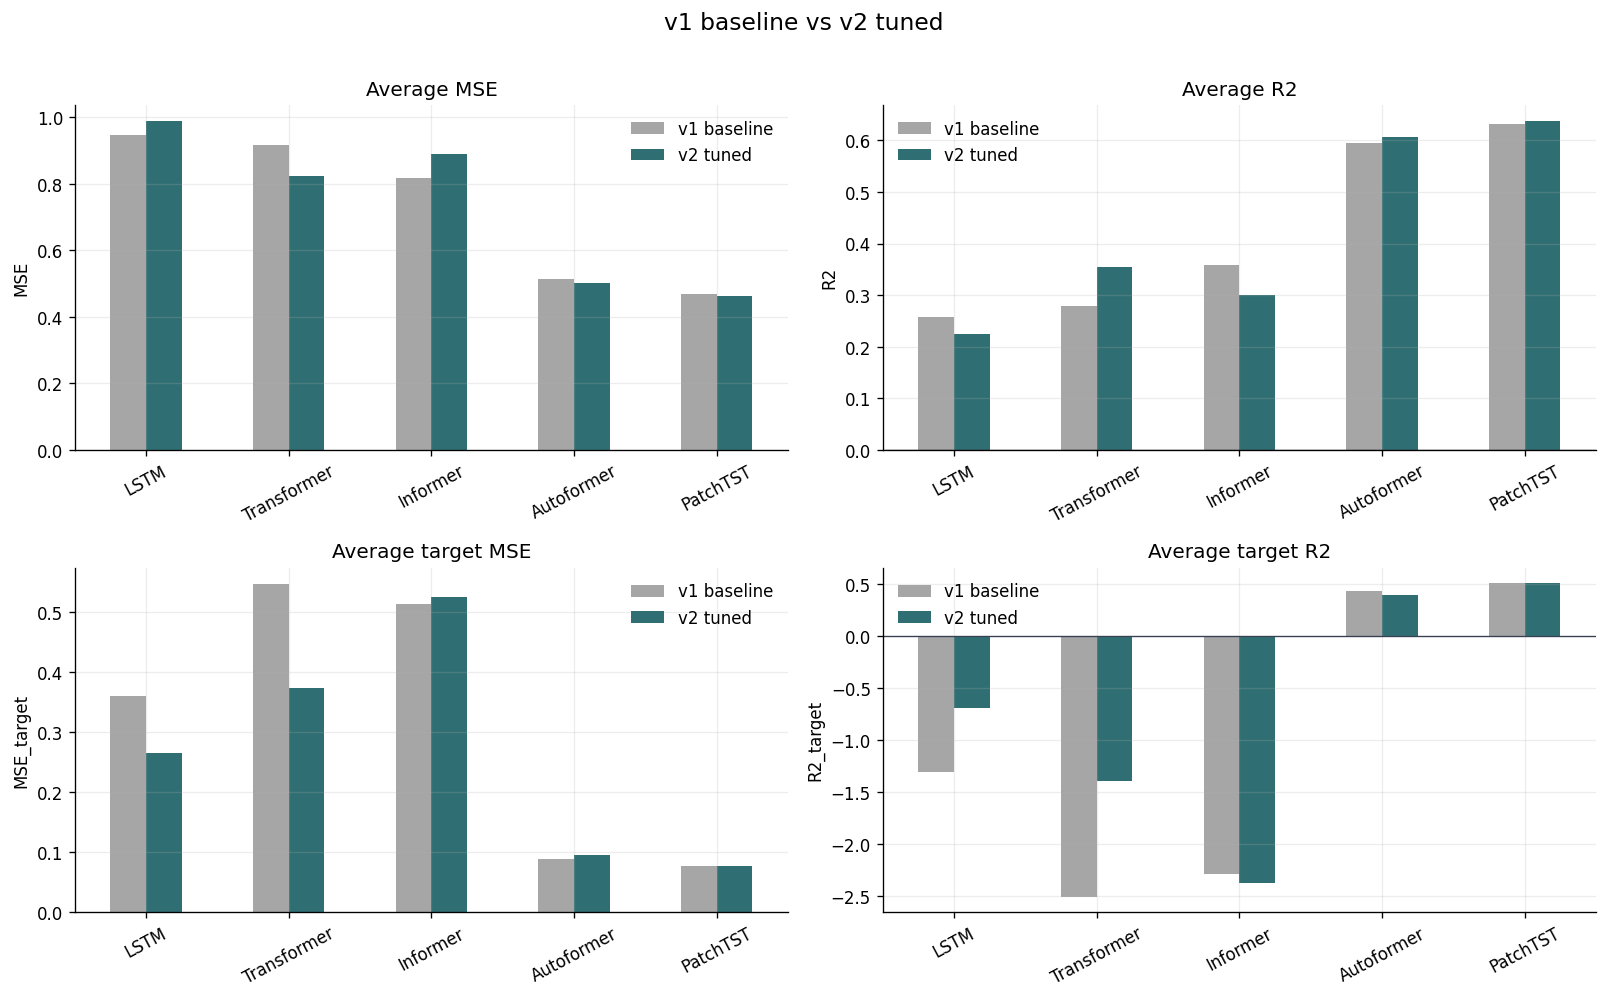

In [7]:
# 四个子图对应两类评价对象（全部变量/目标变量）和两类指标（MSE/R2）。
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.2))
chart_specs = [
    (["MSE_v1", "MSE_v2"], "Average MSE", "MSE"),
    (["R2_v1", "R2_v2"], "Average R2", "R2"),
    (["target_MSE_v1", "target_MSE_v2"], "Average target MSE", "MSE_target"),
    (["target_R2_v1", "target_R2_v2"], "Average target R2", "R2_target"),
]
# 恢复统一模型顺序，确保四张图的横轴完全一致。
plot_data = comparison.set_index("model").reindex(MODEL_ORDER)

# 灰色固定表示 v1，绿色固定表示 v2；R2 图增加 0 线辅助识别负拟合优度。
for ax, (cols, title, ylabel) in zip(axes.ravel(), chart_specs):
    renamed = plot_data[cols].copy()
    renamed.columns = ["v1 baseline", "v2 tuned"]
    renamed.index = [MODEL_LABELS[m] for m in renamed.index]
    renamed.plot(kind="bar", ax=ax, color=["#A6A6A6", "#2F6F73"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=28)
    ax.legend(frameon=False)
    if "R2" in ylabel:
        ax.axhline(0, color="#374151", linewidth=0.8)

fig.suptitle("v1 baseline vs v2 tuned", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_vs_v1_model_comparison.png", bbox_inches="tight")
plt.show()

## 8. v2 相对 v1 的逐任务变化热力图

模型平均值容易掩盖局部退化，因此本节把 50 个配对任务全部展开。

- 单元格数值是 v2 相对 v1 的 MSE 百分比变化；
- 蓝色和负值表示 v2 误差下降；
- 红色和正值表示 v2 误差上升；
- 上排评价全变量，下排评价目标变量。

两张数据集热力图共用同一颜色范围，因此颜色深浅可以跨数据集比较。对于变化幅度异常大的格子，应回查原始 MSE，避免只看百分比。


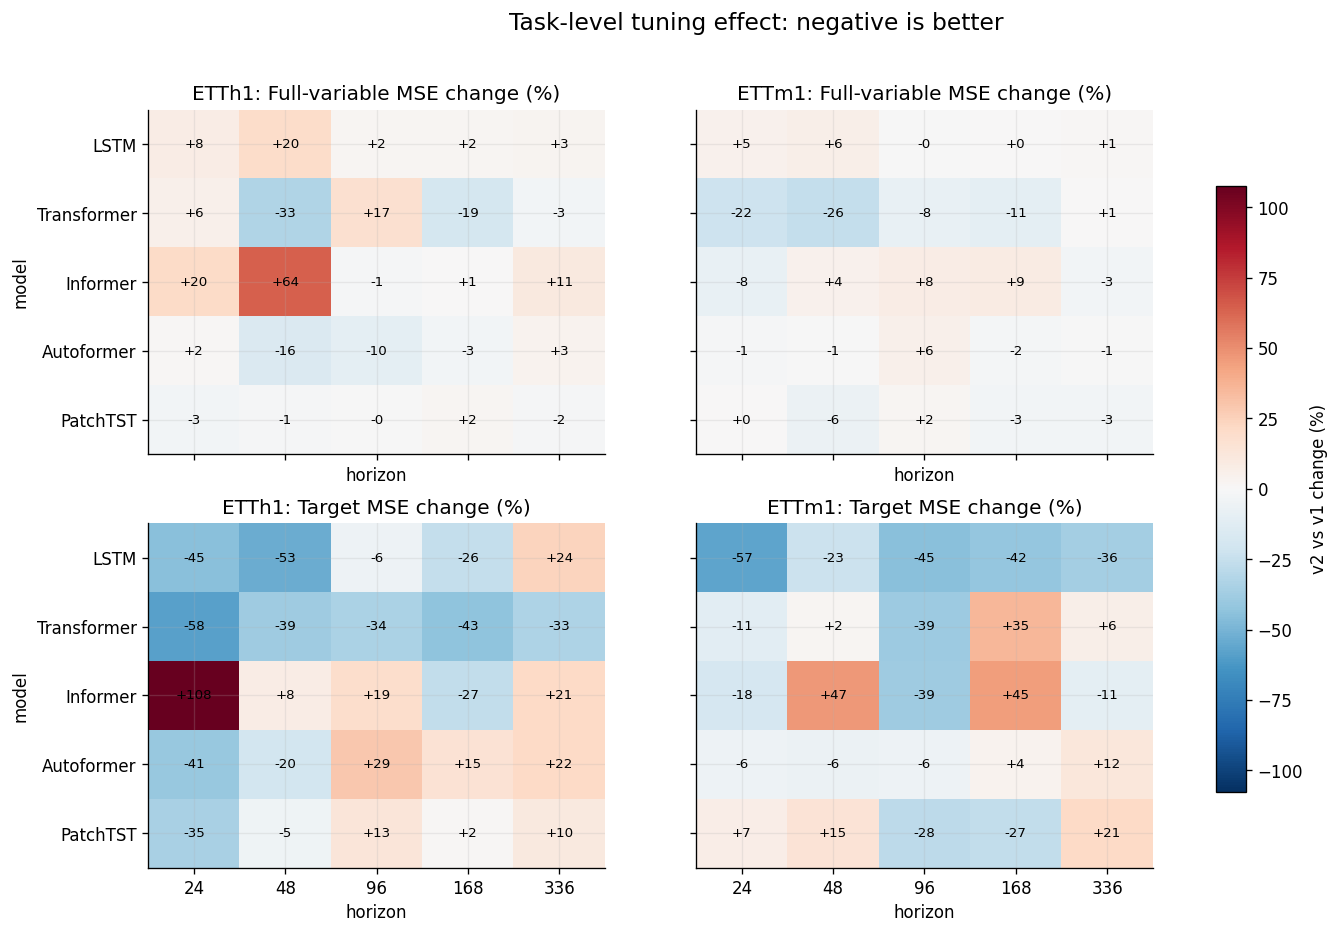

In [8]:
# 在逐任务层面重新计算百分比变化，不使用模型平均值反推，保留每个任务的真实差异。
task_compare = merged.copy()
task_compare["MSE_change_pct"] = (task_compare["MSE_v2"] / task_compare["MSE_v1"] - 1) * 100
task_compare["target_MSE_change_pct"] = (
    task_compare["MSE_target_v2"] / task_compare["MSE_target_v1"] - 1
) * 100

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.2), sharex=True, sharey=True)
metrics = ["MSE_change_pct", "target_MSE_change_pct"]
titles = ["Full-variable MSE change (%)", "Target MSE change (%)"]
# 颜色范围以所有子图中的最大绝对变化为界并关于 0 对称，
# 从而保证同一颜色深度在不同数据集和指标中表示相近的变化幅度。
max_abs = max(abs(task_compare[metrics].min().min()), abs(task_compare[metrics].max().max()))

# 先固定评价口径，再按数据集透视为 model×horizon 矩阵。
for row, (metric, title) in enumerate(zip(metrics, titles)):
    for col, dataset in enumerate(sorted(task_compare["dataset"].unique())):
        ax = axes[row, col]
        pivot = (
            task_compare[task_compare["dataset"] == dataset]
            .pivot(index="model", columns="horizon", values=metric)
            .reindex(MODEL_ORDER)[expected_horizons]
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-max_abs, vmax=max_abs)
        ax.set_title(f"{dataset}: {title}")
        ax.set_xticks(range(len(expected_horizons)))
        ax.set_xticklabels(expected_horizons)
        ax.set_yticks(range(len(MODEL_ORDER)))
        ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
        ax.set_xlabel("horizon")
        if col == 0:
            ax.set_ylabel("model")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                ax.text(j, i, f"{pivot.iloc[i, j]:+.0f}", ha="center", va="center", fontsize=8)

# 四张热力图共享一个颜色条，负值统一表示改善，正值统一表示退化。
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="v2 vs v1 change (%)")
fig.suptitle("Task-level tuning effect: negative is better", y=0.98, fontsize=14)
fig.savefig(FIG_DIR / "v2_vs_v1_task_improvement_heatmap.png", bbox_inches="tight")
plt.show()

## 9. v2 复杂度与性能权衡

散点图同时编码三个量：

- 横轴：平均模型参数量，越靠左模型越小；
- 纵轴：平均 MSE，越靠下预测越准；
- 点面积：完成全部任务的总训练时间，越大表示训练越耗时。

理想模型位于左下角且点较小。但本图中的训练时间来自实际运行记录，会受到 GPU、早停轮数和实现效率影响，因此适合做本项目内部对比，不应直接推广为硬件无关的复杂度结论。


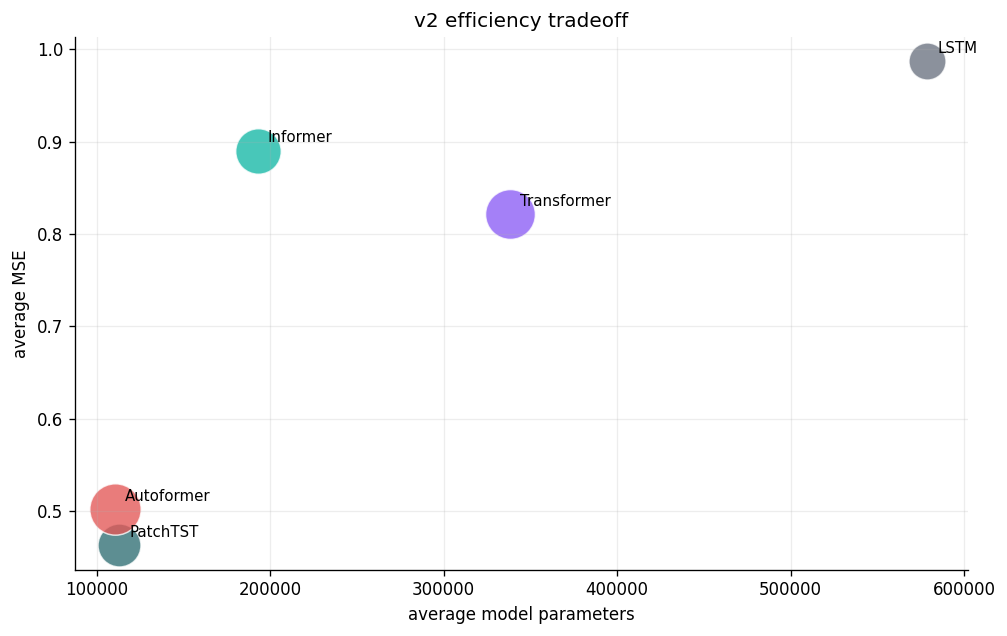

In [9]:
# 使用模型平均表构造效率图；每个点代表一个模型完成整套 v2 任务后的综合表现。
eff = v2_avg.copy()
fig, ax = plt.subplots(figsize=(8.5, 5.4))
# 点面积按总训练时间线性缩放，并加最小面积，防止训练较快的模型几乎不可见。
sizes = eff["train_time_seconds"] / eff["train_time_seconds"].max() * 850 + 100
# 标签直接标在点旁，避免读者在颜色和图例之间来回查找。
for idx, row in eff.iterrows():
    model = row["model"]
    ax.scatter(
        row["model_params"], row["MSE"], s=sizes.loc[idx],
        color=MODEL_COLORS[model], alpha=0.78,
        edgecolor="white", linewidth=0.9,
    )
    ax.annotate(
        MODEL_LABELS[model], (row["model_params"], row["MSE"]),
        xytext=(6, 5), textcoords="offset points", fontsize=9,
    )
ax.set_title("v2 efficiency tradeoff")
ax.set_xlabel("average model parameters")
ax.set_ylabel("average MSE")
fig.tight_layout()
fig.savefig(FIG_DIR / "v2_efficiency_tradeoff.png", bbox_inches="tight")
plt.show()

## 10. 自动结论与输出文件

本节根据当前汇总表动态生成事实性结论，避免手工抄写时把模型名或数值写错。

自动结论可作为报告初稿的核对依据，但仍需人工补充原因分析。例如某模型平均改善明显，可能来自特定数据集或目标变量，而不代表所有任务都改善。输出清单列出本 notebook 实际生成的图，便于报告引用和归档检查。


In [10]:
# v2_avg 已按 MSE 升序排列，因此首行是全变量平均 MSE 最低的模型。
best_v2 = v2_avg.iloc[0]
best_target = v2_avg.sort_values("MSE_target").iloc[0]
# 改善任务数直接从 50 个配对差值统计，而不是根据模型平均值推断。
improved_full = int((task_compare["MSE_change_pct"] < 0).sum())
improved_target = int((task_compare["target_MSE_change_pct"] < 0).sum())
largest_target_gain = comparison.sort_values("target_MSE_change_pct").iloc[0]

# 自动文字只陈述可由数据直接验证的事实，不在代码中替代人工做因果解释。
report_lines = [
    f"v2 完整矩阵包含 {len(v2)} 组实验，与 v1 的 50 个任务一一对应。",
    f"按跨任务平均全变量 MSE，v2 最优模型为 {MODEL_LABELS[best_v2['model']]}，平均 MSE={best_v2['MSE']:.4f}。",
    f"按平均目标变量 MSE，v2 最优模型为 {MODEL_LABELS[best_target['model']]}，平均 MSE_target={best_target['MSE_target']:.4f}。",
    f"与 v1 相比，v2 在 {improved_full}/50 个任务上降低全变量 MSE，在 {improved_target}/50 个任务上降低目标变量 MSE。",
    f"目标变量平均改善最明显的是 {MODEL_LABELS[largest_target_gain['model']]}，MSE_target 变化为 {largest_target_gain['target_MSE_change_pct']:+.1f}%。",
]
display(Markdown("\n".join(f"- {line}" for line in report_lines)))

# 显式维护输出文件清单，便于运行后核对归档目录是否完整。
outputs = [
    "v2_model_average_metrics.png",
    "v2_horizon_trends.png",
    "v2_winner_counts.png",
    "v2_vs_v1_model_comparison.png",
    "v2_vs_v1_task_improvement_heatmap.png",
    "v2_efficiency_tradeoff.png",
]
display(Markdown("**Saved figures**\n\n" + "\n".join(f"- `{name}`" for name in outputs)))

- v2 完整矩阵包含 50 组实验，与 v1 的 50 个任务一一对应。
- 按跨任务平均全变量 MSE，v2 最优模型为 PatchTST，平均 MSE=0.4626。
- 按平均目标变量 MSE，v2 最优模型为 PatchTST，平均 MSE_target=0.0772。
- 与 v1 相比，v2 在 25/50 个任务上降低全变量 MSE，在 29/50 个任务上降低目标变量 MSE。
- 目标变量平均改善最明显的是 Transformer，MSE_target 变化为 -31.6%。

**Saved figures**

- `v2_model_average_metrics.png`
- `v2_horizon_trends.png`
- `v2_winner_counts.png`
- `v2_vs_v1_model_comparison.png`
- `v2_vs_v1_task_improvement_heatmap.png`
- `v2_efficiency_tradeoff.png`